In [1]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pred_500 = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/predicted_all_yeast_full_knockout.csv")
pred_500_rc = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/predicted_all_yeast_full_knockout_rc.csv")

In [3]:
print(pred_500.columns)


Index(['Unnamed: 0.1', 'Unnamed: 0', 'seq_id', 'motif_name', 'seq_200',
       'start_pos', 'offset', 'seq_-30', 'seq_-29', 'seq_-28',
       ...
       'pred_seq_21', 'pred_seq_22', 'pred_seq_23', 'pred_seq_24',
       'pred_seq_25', 'pred_seq_26', 'pred_seq_27', 'pred_seq_28',
       'pred_seq_29', 'pred_seq_30'],
      dtype='object', length=129)


In [4]:
# pred_500[['motif_group', 'motif_type']] = pred_500['motif_name'].str.extract(r'^([^_]+)_([^_]+)')

split_cols = pred_500['motif_name'].str.split('_', n=1, expand=True)
pred_500['motif_group'] = split_cols[0]
pred_500['motif_type'] = split_cols[1]

pred_500_ref = pred_500[pred_500['motif_type'] != 'mut'].copy()
pred_500_alt = pred_500[pred_500['motif_type'] == 'mut'].copy()

pred_500_ref.drop(columns=['motif_type'], inplace=True)
pred_500_alt.drop(columns=['motif_type'], inplace=True)

pred_500_ref = pred_500_ref.rename(columns={col: f"ref_{col}" for col in pred_500_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
pred_500_alt = pred_500_alt.rename(columns={col: f"alt_{col}" for col in pred_500_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df = pd.merge(pred_500_ref, pred_500_alt, on=['seq_id', 'motif_group'], how='inner')

offsets = list(range(-30, 31, 1))

for offset in offsets:
    merged_df[f'diff_{offset}'] =  merged_df[f'ref_pred_seq_{offset}'] - merged_df[f'alt_pred_seq_{offset}']

avg_diff = merged_df.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()

## flipping the signs
# Get the original offsets from column names (excluding 'motif_group')
offsets = [int(col.split("_")[1]) for col in avg_diff.columns if col.startswith("diff_")]


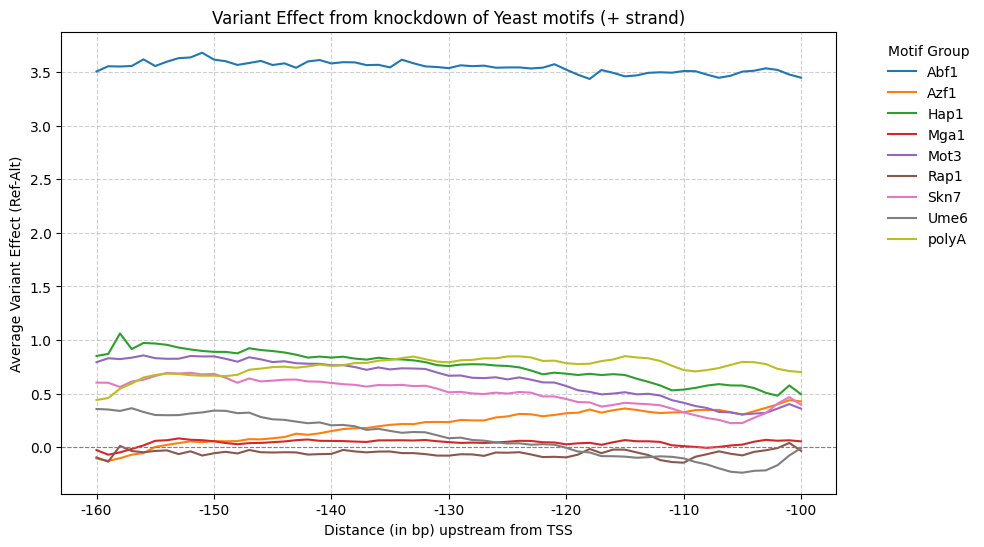

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Set x-axis values (offsets)
offsets = list(range(-30, 31, 1))  # Original offset values

# Map offsets to new range (-160 to -100) using linear scaling
mapped_offsets = np.linspace(-100, -160, len(offsets)) # Linearly map offsets to -160 to -100
# mapped_offsets = offsets
# Select only every 10th tick for display
xticks_positions = mapped_offsets[::10]  # Every 10th position
xticks_labels = [str(int(x)) for x in xticks_positions]  # Convert to integer labels

# Plot each motif_group's diff_offset values
plt.figure(figsize=(10, 6))

for _, row in avg_diff.iterrows():
    plt.plot(mapped_offsets, row[1:], label=row['motif_group'])  # Use mapped offsets

# Formatting
plt.xlabel("Distance (in bp) upstream from TSS")
plt.ylabel("Average Variant Effect (Ref-Alt)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0
plt.xticks(xticks_positions, xticks_labels)  # Apply filtered labels
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left",  frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effect from knockdown of Yeast motifs (+ strand)")
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/yeast_full_knockout.svg",format="svg")

# plt.ylim(-1, 1.05)
# Show plot
plt.show()


### Plot RC

In [6]:
pred_500_rc['motif_group'] = pred_500_rc['motif_name'].str.split('_').str[0]
pred_500_rc['motif_type'] = pred_500_rc['motif_name'].str.split('_').str[1]

pred_500_rc_ref = pred_500_rc[pred_500_rc['motif_type'] != 'mut'].copy()
pred_500_rc_alt = pred_500_rc[pred_500_rc['motif_type'] == 'mut'].copy()

pred_500_rc_ref.drop(columns=['motif_type'], inplace=True)
pred_500_rc_alt.drop(columns=['motif_type'], inplace=True)

pred_500_rc_ref = pred_500_rc_ref.rename(columns={col: f"ref_{col}" for col in pred_500_rc_ref.columns if col not in ['seq_id', 'motif_group', 'motif_name']})
pred_500_rc_alt = pred_500_rc_alt.rename(columns={col: f"alt_{col}" for col in pred_500_rc_alt.columns if col not in ['seq_id', 'motif_group', 'motif_name']})

merged_df_rc = pd.merge(pred_500_rc_ref, pred_500_rc_alt, on=['seq_id', 'motif_group'], how='inner')

offsets = list(range(-30, 31, 1))
# Compute diff_offset for each offset
for offset in offsets:
    merged_df_rc[f'diff_{offset}'] = merged_df_rc[f'ref_pred_seq_{offset}'] - merged_df_rc[f'alt_pred_seq_{offset}']

avg_diff_rc = merged_df_rc.groupby('motif_group')[[f'diff_{offset}' for offset in offsets]].mean().reset_index()

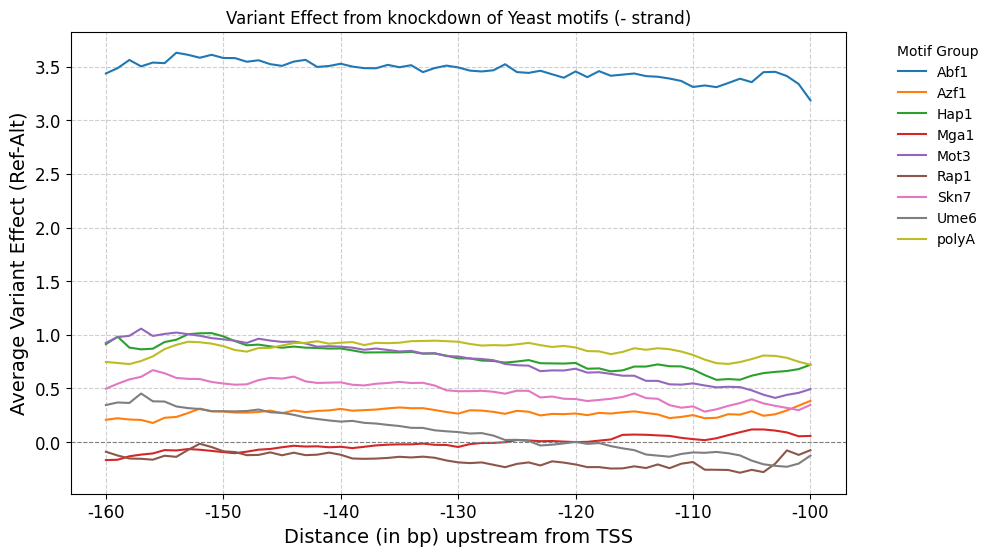

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Set x-axis values (offsets)
offsets = list(range(-30, 31, 1))  # Original offset values

mapped_offsets = np.linspace(-160, -100, len(offsets)) # Linearly map offsets to -160 to -100
# mapped_offsets = offsets
# Select only every 10th tick for display
xticks_positions = mapped_offsets[::10]  # Every 10th position
xticks_labels = [str(int(x)) for x in xticks_positions]  # Convert to integer labels

# Plot each motif_group's diff_offset values
plt.figure(figsize=(10, 6))

for _, row in avg_diff_rc.iterrows():
    plt.plot(mapped_offsets, row[1:], label=row['motif_group'])  # Use mapped offsets

# Formatting
# plt.xlabel("Distance (in bp) upstream from TSS")
# plt.ylabel("Average Variant Effect (Ref-Alt)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)  # Add horizontal line at y=0
# plt.xticks(xticks_positions, xticks_labels) 


plt.xlabel("Distance (in bp) upstream from TSS", fontsize=14)
plt.ylabel("Average Variant Effect (Ref-Alt)", fontsize=14)
plt.xticks(xticks_positions, xticks_labels, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Motif Group", bbox_to_anchor=(1.05, 1), loc="upper left",  frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effect from knockdown of Yeast motifs (- strand)")
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/yeast_full_knockout_rc.svg",format="svg")


# Show plot
plt.show()

### Plot individual TFs

In [8]:
# Get original offset columns
offset_cols = [col for col in avg_diff.columns if col.startswith("diff_")]

# Build mapping: diff_-10 → diff_10, diff_15 → diff_-15, etc.
flipped_cols = {f'diff_{offset}': f'diff_{-int(offset)}' for offset in [col.split("_")[1] for col in offset_cols]}

# Rename columns in avg_diff
avg_diff_flipped = avg_diff.rename(columns=flipped_cols)
avg_diff_flipped['strand'] = 'forward'

avg_diff_rc['strand'] = 'reverse'
combined_diff = pd.concat([avg_diff_rc, avg_diff_flipped], ignore_index=True)


# Extract diff columns (e.g., diff_-30 to diff_30)
offset_cols = [col for col in combined_diff.columns if col.startswith("diff_")]

# Sort by numeric offset
offsets = list(range(-30, 31, 1))  # Original offset values
mapped_offsets = np.linspace(-160, -100, len(offsets))



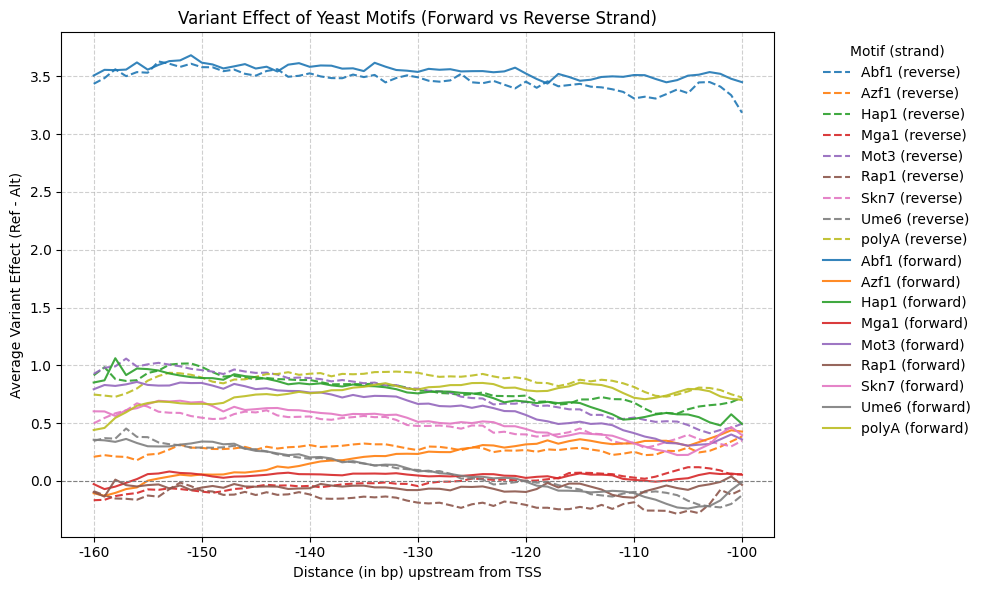

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Optional color palette: consistent color but different line styles for strand
palette = sns.color_palette("tab10", n_colors=len(combined_diff['motif_group'].unique()))
motif_colors = {motif: palette[i] for i, motif in enumerate(combined_diff['motif_group'].unique())}

# Prepare ticks
xticks_positions = mapped_offsets[::10]
xticks_labels = [str(int(x)) for x in xticks_positions]

plt.figure(figsize=(10, 6))

# Plot
for _, row in combined_diff.iterrows():
    motif = row['motif_group']
    strand = row['strand']
    values = row[offset_cols].astype(float).values

    label = f"{motif} ({strand})"
    linestyle = '-' if strand == 'forward' else '--'

    plt.plot(mapped_offsets, values, label=label, color=motif_colors[motif], linestyle=linestyle, alpha=0.9)

# Formatting
plt.xlabel("Distance (in bp) upstream from TSS")
plt.ylabel("Average Variant Effect (Ref - Alt)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xticks(xticks_positions, xticks_labels)
plt.grid(True, linestyle="--", alpha=0.6)
plt.title("Variant Effect of Yeast Motifs (Forward vs Reverse Strand)")
plt.legend(title="Motif (strand)", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.tight_layout()

# Save + show
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/yeast_combined_strands.svg", format="svg")
plt.show()


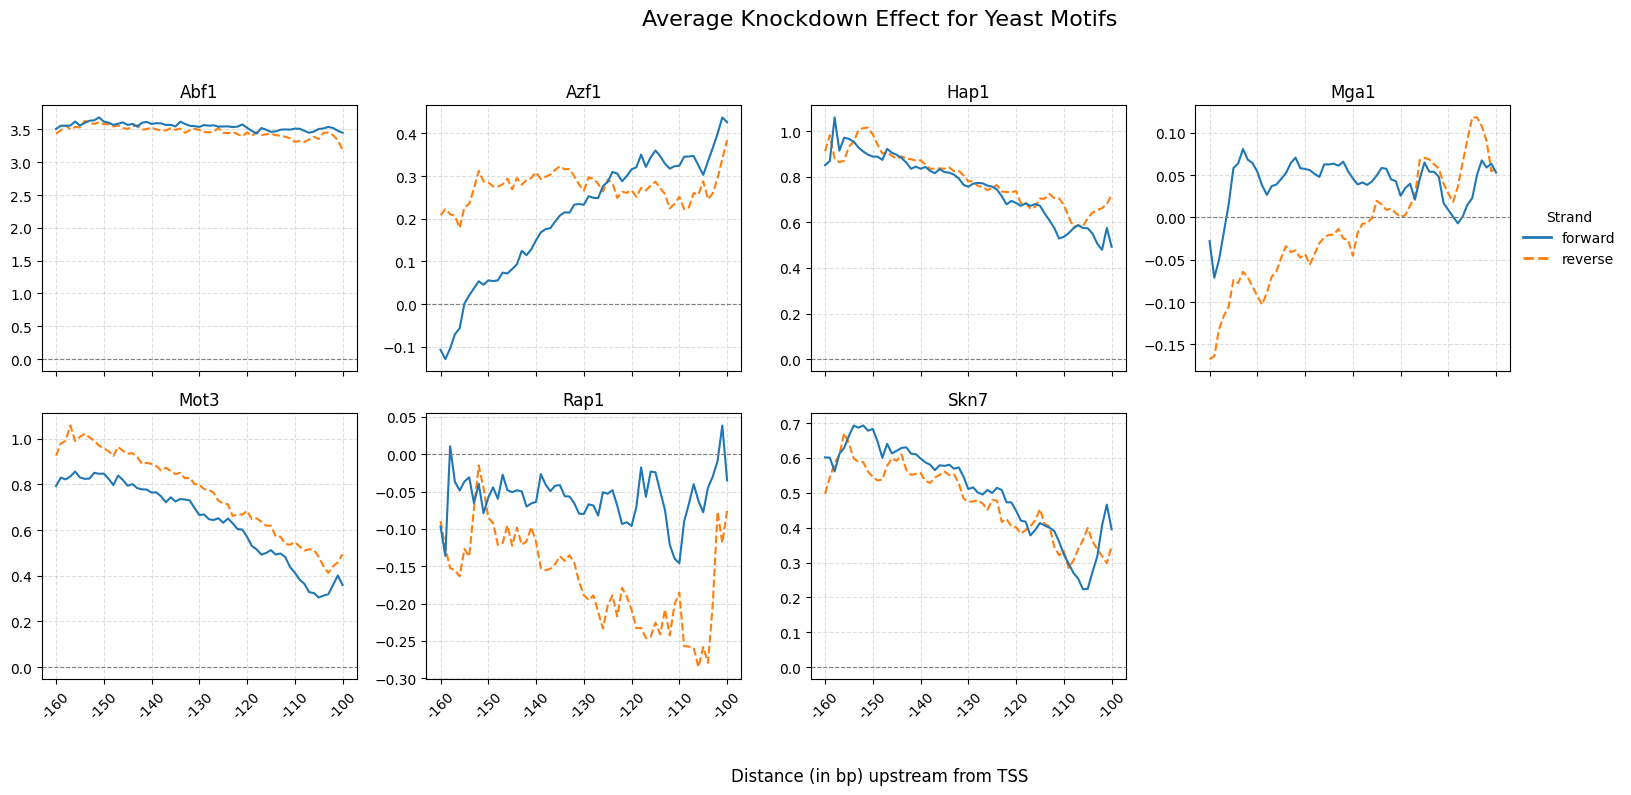

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Pick 7 motifs (or use .unique()[:7])
motifs_to_plot = combined_diff['motif_group'].unique()[:7]

# Genomic x-axis
xticks_positions = mapped_offsets[::10]
xticks_labels = [str(int(x)) for x in xticks_positions]

# Create subplot grid: 2 rows, 4 columns (7 plots total)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=False)
axes = axes.flatten()  
for i, motif in enumerate(motifs_to_plot):
    ax = axes[i]
    df_motif = combined_diff[combined_diff['motif_group'] == motif]

    color_forward = '#1f77b4'  # blue
    color_reverse = '#ff7f0e'  # orange

    for _, row in df_motif.iterrows():
        strand = row['strand']
        values = row[offset_cols].astype(float).values
        linestyle = '-' if strand == 'forward' else '--'
        label = f"{strand}" if i == 0 else None

        color = color_forward if strand == 'forward' else color_reverse

        ax.plot(mapped_offsets, values, linestyle=linestyle, label=label, color=color)


    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(motif)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks(xticks_positions)
    ax.set_xticklabels(xticks_labels, rotation=45)

# Common labels
fig.supxlabel("Distance (in bp) upstream from TSS")
fig.supylabel("")
fig.suptitle("Average Knockdown Effect for Yeast Motifs", fontsize=16)

from matplotlib.lines import Line2D

custom_lines = [
    Line2D([0], [0], color='#1f77b4', lw=2, linestyle='-', label='forward'),
    Line2D([0], [0], color='#ff7f0e', lw=2, linestyle='--', label='reverse')
]

axes[3].legend(
    handles=custom_lines,
    title="Strand",
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    frameon=False
)

# Hide unused subplot if < 8
if len(motifs_to_plot) < len(axes):
    for j in range(len(motifs_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 0.92, 0.95])  # adjust right margin so legend fits

plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/panel_7motifs.svg", format="svg")
plt.show()


### I now want to plot the biochemical model signals on this same plot

/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


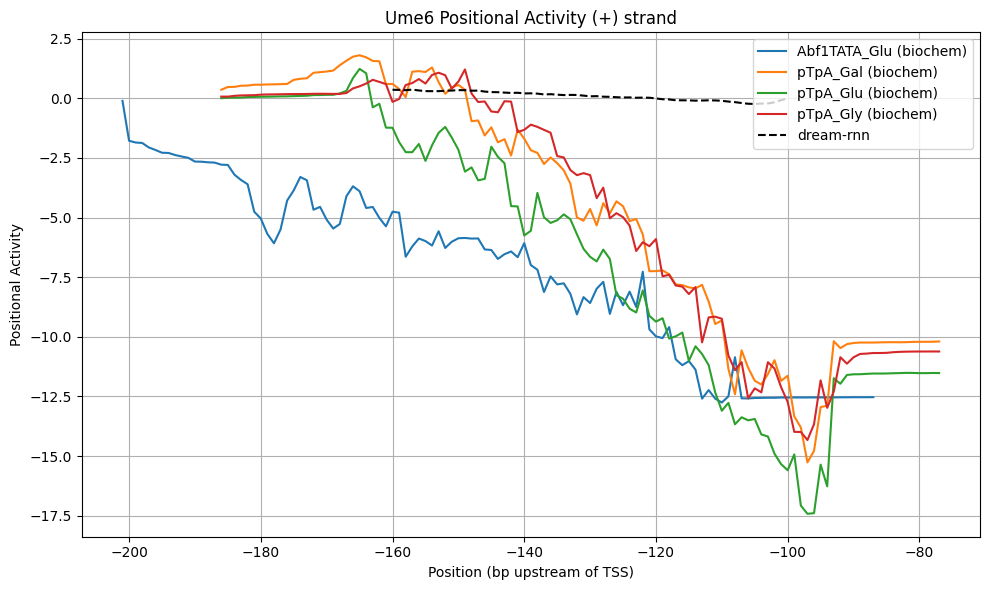

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

motif = "Ume6"

# Load biochemical data
file_path = "/scratch/st-cdeboer-1/sambina/position_mpra/data/TF_position/yeast/41587_2019_315_MOESM6_ESM.xlsx"
biochemical = pd.read_excel(file_path, sheet_name="positional params - positional", engine="openpyxl", skiprows=1)
df_ABF1 = biochemical[biochemical["TFAlias"] == motif.upper()].sort_values(by="position")

# Load DREAM model data
df_dream = combined_diff[combined_diff["motif_group"] == motif]

# Colors
dream_colors = {"forward": "#000000", "reverse": "#000000"}

# Start plotting
plt.figure(figsize=(10, 6))

# Plot biochemical positional activity (+ strand)
for dataset, group in df_ABF1.groupby("Dataset"):
    plt.plot(group["position"], group["positionalActivity"], label=f"{dataset} (biochem)", linestyle='-')

# Plot DREAM forward strand
label_added = False
for _, row in df_dream[df_dream["strand"] == "forward"].iterrows():
    y = row[offset_cols].astype(float).values
    plt.plot(mapped_offsets, y, linestyle='--', color=dream_colors["forward"],
             label="dream-rnn" if not label_added else None)
    label_added = True


# Labels and legend
plt.title(f"{motif} Positional Activity (+) strand")
plt.xlabel("Position (bp upstream of TSS)")
plt.ylabel("Positional Activity")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


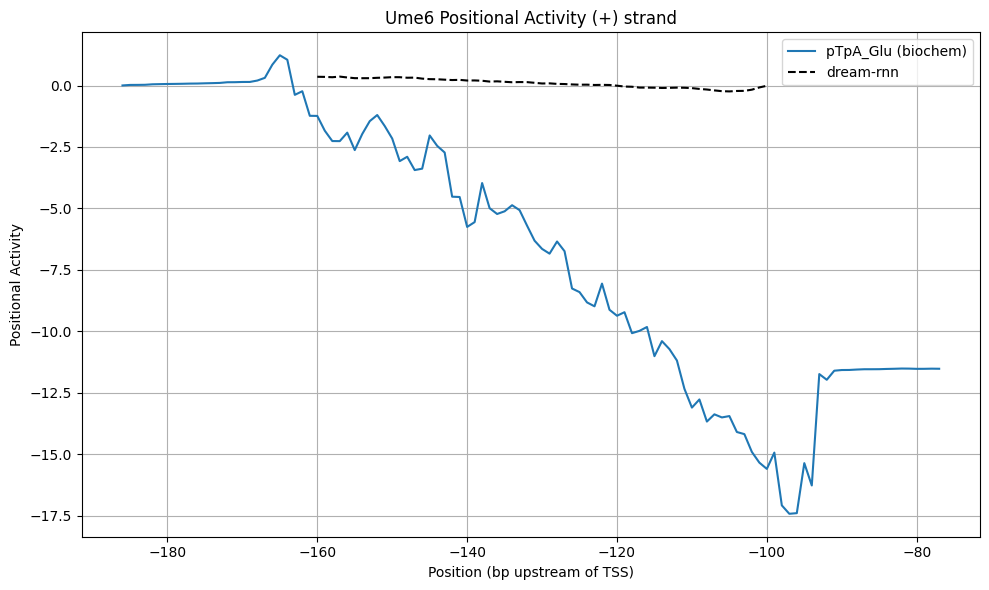

In [42]:
plt.figure(figsize=(10, 6))

# Filtered biochemical data
df_ABF1_filtered = df_ABF1[df_ABF1["Dataset"] == "pTpA_Glu"]

# Plot biochemical positional activity
for dataset, group in df_ABF1_filtered.groupby("Dataset"):
    plt.plot(group["position"], group["positionalActivity"], label=f"{dataset} (biochem)", linestyle='-')

# Plot DREAM forward strand
label_added = False
for _, row in df_dream[df_dream["strand"] == "forward"].iterrows():
    y = row[offset_cols].astype(float).values
    plt.plot(mapped_offsets, y, linestyle='--', color=dream_colors["forward"],
             label="dream-rnn" if not label_added else None)
    label_added = True

# Labels and legend
plt.title(f"{motif} Positional Activity (+) strand")
plt.xlabel("Position (bp upstream of TSS)")
plt.ylabel("Positional Activity")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


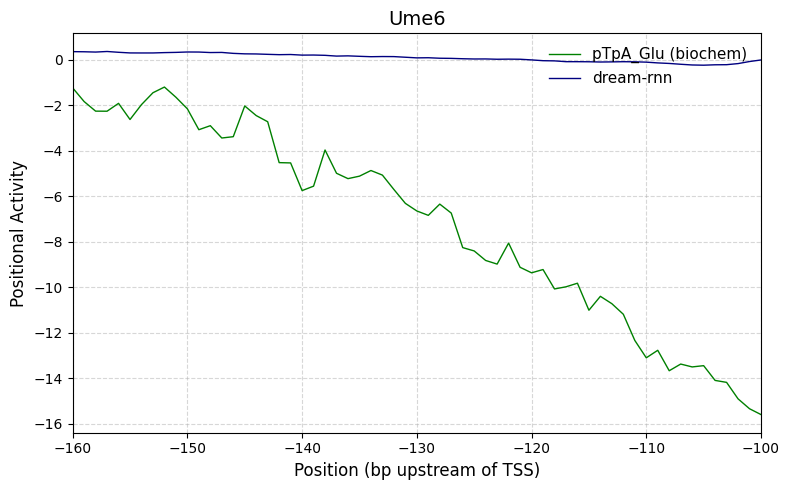

In [43]:
plt.figure(figsize=(8, 5))  # slightly smaller for pub figures

# Filtered biochemical data for Dataset and position range
df_ABF1_filtered = df_ABF1[
    (df_ABF1["Dataset"] == "pTpA_Glu") & 
    (df_ABF1["position"].between(-160, -100))
]

# Plot biochemical positional activity (green) with markers
plt.plot(
    df_ABF1_filtered["position"], 
    df_ABF1_filtered["positionalActivity"], 
    label="pTpA_Glu (biochem)", 
    color="green", 
    linestyle='-', 
    linewidth=1,
    markersize=4
)

# Plot DREAM forward strand (navy blue) thicker dashed line
y_vals = df_dream[df_dream["strand"] == "forward"][offset_cols].astype(float).mean(axis=0).values
plt.plot(
    mapped_offsets, 
    y_vals, 
    linestyle='-', 
    color="navy", 
    label="dream-rnn",
    linewidth=1
)

# Labels, legend, and axes styling
plt.title(f"{motif}", fontsize=14)
plt.xlabel("Position (bp upstream of TSS)", fontsize=12)
plt.ylabel("Positional Activity", fontsize=12)
plt.xlim(-160, -100)  # focus on the range of interest
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc="upper right", fontsize=11, frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)  # subtle dashed grid
plt.tight_layout()
plt.savefig(f"/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/{motif}_forward.svg")

plt.show()


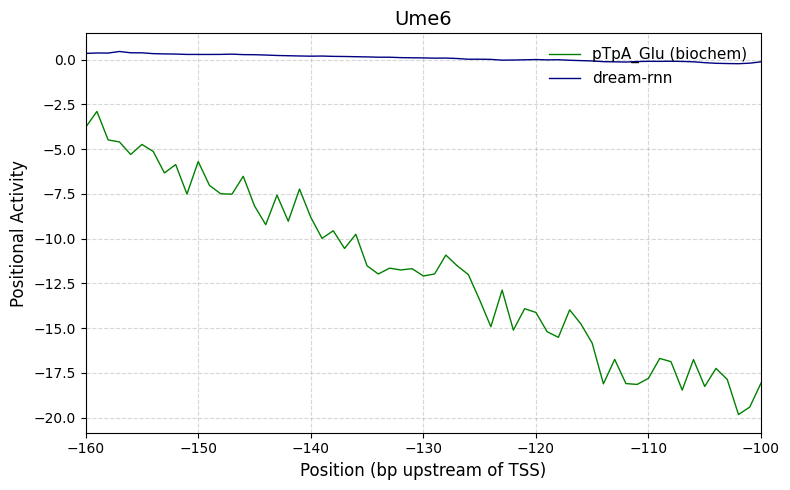

In [44]:
plt.figure(figsize=(8, 5))  # slightly smaller for pub figures

# Filtered biochemical data for Dataset and position range
df_ABF1_filtered = df_ABF1[
    (df_ABF1["Dataset"] == "pTpA_Glu") & 
    (df_ABF1["position"].between(-160, -100))
]

# Plot biochemical positional activity (green) with markers
plt.plot(
    df_ABF1_filtered["position"], 
    df_ABF1_filtered["positionalActivityRC"], 
    label="pTpA_Glu (biochem)", 
    color="green", 
    linestyle='-', 
    linewidth=1,
    markersize=4
)

# Plot DREAM forward strand (navy blue) thicker dashed line
y_vals = df_dream[df_dream["strand"] == "reverse"][offset_cols].astype(float).mean(axis=0).values
plt.plot(
    mapped_offsets, 
    y_vals, 
    linestyle='-', 
    color="navy", 
    label="dream-rnn",
    linewidth=1
)

# Labels, legend, and axes styling
plt.title(f"{motif}", fontsize=14)
plt.xlabel("Position (bp upstream of TSS)", fontsize=12)
plt.ylabel("Positional Activity", fontsize=12)
plt.xlim(-160, -100)  # focus on the range of interest
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(loc="upper right", fontsize=11, frameon=False)
plt.grid(True, linestyle='--', alpha=0.5)  # subtle dashed grid
plt.tight_layout()
plt.savefig(f"/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/{motif}_reverse.svg")

plt.show()


#### Plotting the heatmap ####

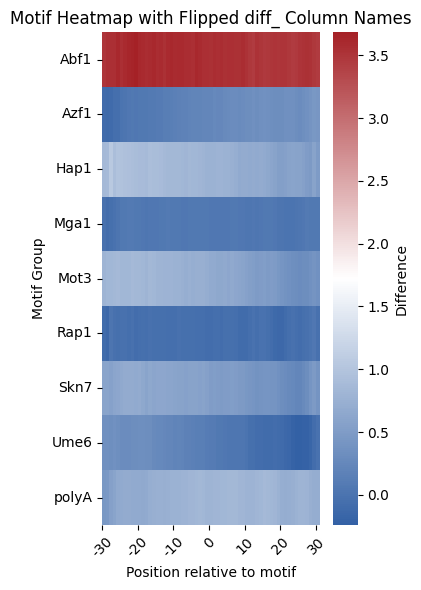

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import re

# Identify diff_ columns
diff_cols = [col for col in avg_diff.columns if col.startswith("diff_")]

# Create a mapping from old column names to new with flipped sign
new_diff_cols = {}
for col in diff_cols:
    num = int(col.replace("diff_", ""))  # get number
    flipped_num = -num  # flip sign
    new_diff_cols[col] = f"diff_{flipped_num}"

# Rename columns
avg_diff = avg_diff.rename(columns=new_diff_cols)

# Prepare numeric data for heatmap
data = avg_diff[[col for col in avg_diff.columns if col.startswith("diff_")]]

# Extract positions as ints for x-axis
positions = [int(c.replace("diff_", "")) for c in data.columns]

# Sort columns in ascending order of position
sorted_cols = [f"diff_{p}" for p in sorted(positions)]
data = data[sorted_cols]
positions = sorted(positions)

# Y-axis labels
y_labels = list(avg_diff['motif_group'])

# Colormap
colors = ['#3361A5', '#ffffff', '#A52126']
cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', colors, N=256)
xticks_positions = np.arange(min(positions), max(positions) + 1, 10)
xticks_indices = [positions.index(pos) for pos in xticks_positions if pos in positions]

# Plot heatmap
plt.figure(figsize=(4, max(6, len(avg_diff)*0.15)))
sns.heatmap(
    data,
    cmap=cmap,
    yticklabels=y_labels,
    xticklabels=positions,
    cbar_kws={"label": "Difference"},
)
plt.yticks(rotation=0)
plt.xticks(xticks_indices, xticks_positions, rotation=45)

plt.xlabel("Position relative to motif")
plt.ylabel("Motif Group")
plt.title("Motif Heatmap with Flipped diff_ Column Names")
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/avg_knockout.png", dpi=600)
plt.show()


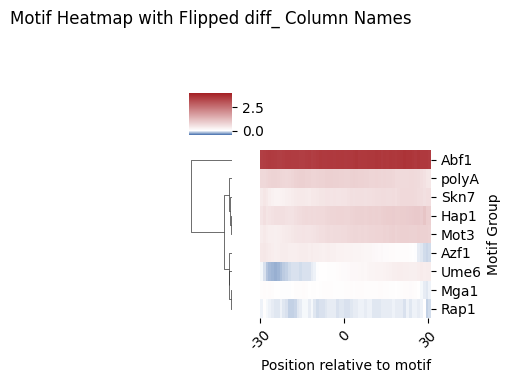

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Identify diff_ columns
diff_cols = [col for col in avg_diff.columns if col.startswith("diff_")]
# Create a mapping from old column names to new with flipped sign
new_diff_cols = {}
for col in diff_cols:
    num = int(col.replace("diff_", ""))  # get number
    flipped_num = -num  # flip sign
    new_diff_cols[col] = f"diff_{flipped_num}"

# Rename columns
avg_diff = avg_diff.rename(columns=new_diff_cols)


data = avg_diff[diff_cols].copy()  # numeric data only

# Extract positions as ints for x-axis
positions = [int(c.replace("diff_", "")) for c in data.columns]

# Sort columns in ascending order
sorted_cols = [f"diff_{p}" for p in sorted(positions)]
data = data[sorted_cols]
positions = sorted(positions)

# Colormap: white at 0
vmin, vmax = -0.5, 4
white_pos = -vmin / (vmax - vmin)
colors = [(0.0, "#3361A5"), (white_pos, "#ffffff"), (1.0, "#A52126")]
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# Full data matrix for clustermap (motif_group as index)
data_matrix = data.copy()
data_matrix.index = avg_diff['motif_group']

# X-tick positions
xticks_positions = np.arange(min(positions), max(positions)+1, 30)
xticks_indices = [positions.index(pos) for pos in xticks_positions if pos in positions]

# Plot clustermap
g = sns.clustermap(
    data_matrix,
    cmap=cmap,
    row_cluster=True,
    col_cluster=False,        # keep positions in order
    figsize=(3.5, max(4, len(data_matrix) * 0.75 * 0.15)),
    yticklabels=True,
    xticklabels=False,
    vmin=vmin,
    vmax=vmax,
)

# Set x-axis ticks on heatmap
g.ax_heatmap.set_xticks(xticks_indices)
g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

g.ax_heatmap.set_xlabel("Position relative to motif")
g.ax_heatmap.set_ylabel("Motif Group")
plt.title("Motif Heatmap with Flipped diff_ Column Names", pad=50)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/avg_knockout.svg",
    dpi=600
)

plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/avg_knockout.png",
    dpi=600
)
plt.show()


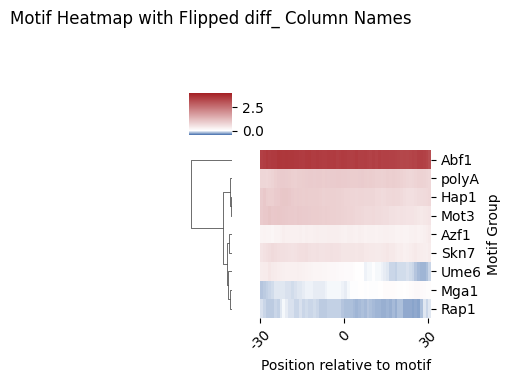

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Identify diff_ columns
diff_cols = [col for col in avg_diff_rc.columns if col.startswith("diff_")]

# If you wanted to flip sign, do it here (optional)
data = avg_diff_rc[diff_cols].copy()  # numeric data only

# Extract positions as ints for x-axis
positions = [int(c.replace("diff_", "")) for c in data.columns]

# Sort columns in ascending order
sorted_cols = [f"diff_{p}" for p in sorted(positions)]
data = data[sorted_cols]
positions = sorted(positions)

# Colormap: white at 0
vmin, vmax = -0.5, 4
white_pos = -vmin / (vmax - vmin)
colors = [(0.0, "#3361A5"), (white_pos, "#ffffff"), (1.0, "#A52126")]
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# Full data matrix for clustermap (motif_group as index)
data_matrix = data.copy()
data_matrix.index = avg_diff_rc['motif_group']

# X-tick positions
xticks_positions = np.arange(min(positions), max(positions)+1, 30)
xticks_indices = [positions.index(pos) for pos in xticks_positions if pos in positions]

# Plot clustermap
g = sns.clustermap(
    data_matrix,
    cmap=cmap,
    row_cluster=True,
    col_cluster=False,        # keep positions in order
    figsize=(3.5, max(4, len(data_matrix) * 0.75 * 0.05)),
    yticklabels=True,
    xticklabels=False,
    vmin=vmin,
    vmax=vmax,
)

# Set x-axis ticks on heatmap
g.ax_heatmap.set_xticks(xticks_indices)
g.ax_heatmap.set_xticklabels(xticks_positions, rotation=45)

g.ax_heatmap.set_xlabel("Position relative to motif")
g.ax_heatmap.set_ylabel("Motif Group")
plt.title("Motif Heatmap with Flipped diff_ Column Names", pad=50)

plt.tight_layout()
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/avg_knockout_rc.svg",
    dpi=600
)
plt.savefig(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/TFs_position/yeast/avg_knockout_rc.png",
    dpi=600
)
plt.show()


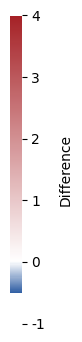

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colorbar as mcolorbar

# Colormap & limits (same as your heatmap)
vmin, vmax = -0.5, 4
white_pos = -vmin / (vmax - vmin)
colors = [(0.0, "#3361A5"), (white_pos, "#ffffff"), (1.0, "#A52126")]
cmap = LinearSegmentedColormap.from_list("custom_blue_white_red", colors, N=256)

# Create figure for colorbar
fig, ax = plt.subplots(figsize=(0.15, 4.0))
norm = Normalize(vmin=vmin, vmax=vmax)
cb = mcolorbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical')

# Remove the black border (outline) and ticks on the bar's frame
cb.outline.set_visible(False)

# Set ticks every 1 unit
ticks = np.arange(np.floor(vmin), np.ceil(vmax) + 1, 1)
cb.set_ticks(ticks)
cb.set_ticklabels([str(int(t)) if t.is_integer() else str(t) for t in ticks])

# Label
cb.set_label("Difference", rotation=90, labelpad=10)

plt.savefig("separate_colorbar.svg", dpi=600, bbox_inches="tight")
plt.show()

